In [65]:
import pylab as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.io import savemat
from matplotlib.gridspec import GridSpec
from math import radians,sin,asin,sqrt,cos
import cmocean

import sys
import array
from scipy.interpolate import griddata
from scipy.interpolate import make_smoothing_spline

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import FixedLocator

import warnings
warnings.filterwarnings('ignore')

In [2]:
import gsw

In [3]:
gsw.density.sigma0(34, np.mean(tempS))+1000

NameError: name 'tempS' is not defined

In [4]:
np.mean(tempS)

NameError: name 'tempS' is not defined

In [2]:
def map_gol_cal(fig,ax,limites=None):
    """
    Mercator map of the Gulf of California
    limites = [south, north, west, east] (lon negative)
    """
    if limites is None or len(limites) == 0:
        limites = [22, 32, -116, -105]

    lat_s, lat_n, lon_w, lon_e = limites

    ax.set_extent([lon_w, lon_e, lat_s, lat_n],
                  crs=ccrs.PlateCarree())

    # Coast & land
    ax.add_feature(cfeature.LAND, facecolor='0.7')
    ax.add_feature(cfeature.COASTLINE, linewidth=1)

    # ---- GRIDLINES: LABELS ONLY, NO VISIBLE LINES ----
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0,        # <-- hides grid lines
        linestyle='--'
    )

    gl.top_labels = False
    gl.right_labels = False

    gl.xformatter = LongitudeFormatter(degree_symbol='°')
    gl.yformatter = LatitudeFormatter(degree_symbol='°')
    return ax

def plot_square(x_start, y_start, x_end,y_end,ax):
    """Plots a square by defining its four corners and connecting them with lines."""
    x_coords = [x_start, x_end, x_end, x_start,x_start]
    y_coords = [y_start, y_start, y_end, y_end, y_start]
    
    ax.plot(x_coords, y_coords, color='red', linewidth=4,linestyle='solid',transform=ccrs.PlateCarree())
    

In [3]:
dz = 1
arch_out = "../batimetria/bat_surfer_grd.mat"
op_out = True

latmin =28 + 12/60
latmax =30
lonmin =111.8
lonmax = 114.0

limites = [latmin, latmax, -lonmax, -lonmin]

latmin1 =28.65 #28 + 12/60
latmax1 =29.1 #30
lonmin1 = 112.85#111.8
lonmax1 = 113.15#114.0

limites1 = [latmin1, latmax1, -lonmax1, -lonmin1]

latmin2 =29.45 #28 + 12/60
latmax2 =29.85 #30
lonmin2 = 113.2#111.8
lonmax2 = 113.65#114.0

limites2 = [latmin2, latmax2, -lonmax2, -lonmin2]

nx = 500   # longitude dimension
ny = 430   # latitude dimension

tray_bat = "../batimetria/alby0203_surf_grd.dat"

data = np.loadtxt(tray_bat)

lon_b = data[:, 0]
lat_b = data[:, 1]
bat   = data[:, 2]


lat_b = lat_b.reshape(nx, ny, order="F").T
lon_b = lon_b.reshape(nx, ny, order="F").T
bat   = bat.reshape(nx, ny, order="F").T


mask = lat_b <= latmax
iy, ix = np.where(mask)

iy1, iy2 = iy.min(), iy.max()
ix1, ix2 = ix.min(), ix.max()

lat_b = lat_b[iy1:iy2 + 1, ix1:ix2 + 1]
lon_b = lon_b[iy1:iy2 + 1, ix1:ix2 + 1]
bat   = bat[iy1:iy2 + 1, ix1:ix2 + 1]

ny2, nx2 = lat_b.shape


In [4]:
maskin = np.logical_and(np.logical_and(lat_b <= latmax,lat_b>= latmin),np.logical_and(lon_b >= -lonmax,lon_b <= -lonmin))==False
maskin1 = np.logical_and(np.logical_and(lat_b <= latmax1,lat_b>= latmin1),np.logical_and(lon_b >= -lonmax1,lon_b <= -lonmin1))==False
maskin2 = np.logical_and(np.logical_and(lat_b <= latmax2,lat_b>= latmin2),np.logical_and(lon_b >= -lonmax2,lon_b <= -lonmin2))==False


In [5]:
def haversine(lon1, lat1, lon2, lat2):

# ######   Calculate the great circle distance in kilometers between two points on the earth (specified in decimal degrees)
    # convert decimal degrees to radians 
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    return c * r

In [6]:
latsin=np.linspace(28.73,28.99,9)

latsin[5]=latsin[5]-0.02
latsin[6]=latsin[6]+0.05
latsin[7]=latsin[7]-0.03
latsin[8]=latsin[8]+0.05

In [7]:
bat_deep = np.ma.masked_where(bat > -300, bat)

In [8]:
indexesY=np.zeros(len(latsin))
indexesX=np.zeros(len(latsin))
for i in range(len(latsin)):
    indexesY[i]=np.where(lat_b[:,0]>=latsin[i])[0][0]
    if i==0:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][3]
    elif i==2:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][2]
    elif i==4:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][4]
    elif i==5:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][3]
    elif i==6:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][4]
    elif i==7:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][3]
    elif i==8:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][4]
    else:
        indexesX[i]=np.where(np.logical_and(bat_deep[indexesY[i].astype(int),:]<-350,bat_deep[indexesY[i].astype(int),:]>-450))[0][1]

In [9]:
lonsin=np.linspace(113.65,113.3,9)
#lonsin[5:]=lonsin[5:]+0.02

In [10]:
indexesY2=np.zeros(len(lonsin))
indexesX2=np.zeros(len(lonsin))
for i in range(len(lonsin)):
    indexesX2[i]=np.where(lon_b[0,:]>=-lonsin[i])[0][0]
    if i==2:
        indexesY2[i]=np.where(np.logical_and(bat_deep[:,indexesX2[i].astype(int)]<-180,bat_deep[:,indexesX2[i].astype(int)]>-220))[0][3]
    elif i==5:
        indexesY2[i]=np.where(np.logical_and(bat_deep[:,indexesX2[i].astype(int)]<-180,bat_deep[:,indexesX2[i].astype(int)]>-220))[0][5]
    elif i==6:
        indexesY2[i]=np.where(np.logical_and(bat_deep[:,indexesX2[i].astype(int)]<-180,bat_deep[:,indexesX2[i].astype(int)]>-220))[0][1]
    elif i==8:
        indexesY2[i]=np.where(np.logical_and(bat_deep[:,indexesX2[i].astype(int)]<-180,bat_deep[:,indexesX2[i].astype(int)]>-220))[0][1]
    else:
        indexesY2[i]=np.where(np.logical_and(bat_deep[:,indexesX2[i].astype(int)]<-180,bat_deep[:,indexesX2[i].astype(int)]>-220))[0][4]

In [11]:

lon_pt1, lat_pt1 = -112.612, 28.429
lon_pt11, lat_pt11 = -112.628, 28.413

lon_pt2, lat_pt2 = -113.6, 29.4
lon_pt12, lat_pt12 = -113.665, 29.315

lon_pt3, lat_pt3 = -112.725, 28.6
lon_pt13, lat_pt13 = -112.68, 28.65

lon_pt4, lat_pt4 = -113.58, 29.63
lon_pt14, lat_pt14 = -113.56, 29.81

lon=np.array([-112.5,-113.025])
lon=np.append(lon,np.array([-113.3,-113.95]))
lon=np.append(lon,lon_b[indexesY2.astype(int),indexesX2.astype(int)])
lon=np.append(lon,np.array([-113.18]))
lon=np.append(lon,np.flip(lon_b[indexesY.astype(int),indexesX.astype(int)]))
lon=np.append(lon,np.array([-112.7,-112.5]))


lat=np.array([28.35,28.74])
lat=np.append(lat,np.array([29,29.7]))
lat=np.append(lat,lat_b[indexesY2.astype(int),indexesX2.astype(int)])
lat=np.append(lat,np.array([29.45]))
lat=np.append(lat,np.flip(lat_b[indexesY.astype(int),indexesX.astype(int)]))
lat=np.append(lat,np.array([28.6,28.4]))

In [12]:
dist_array = np.zeros(len(lon)-1)
p=0
for jj in range(len(lon)-1):
    lat1 = lat[jj+1]
    lon1 = lon[jj+1]
    lat2 = lat[jj]
    lon2 = lon[jj]
    p=p+1
    dist_array[p-1]=  haversine(lat1, lon1, lat2, lon2)
    
dist_cummul = np.cumsum(dist_array)

In [13]:
lon_umb_cb=-(113 + 38.710/60)
lat_umb_cb=29 + 20.605/60
lon_umb_sl=-(112 + 37.388/60)
lat_umb_sl=28 + 25.439/60
lon_umb_se=-(112 + 41.593/60)
lat_umb_se=28 + 37.041/60
lon_umb_del=-(113 + 23.492/60)
lat_umb_del=29 + 38.788/60


In [14]:
lon_Baty=np.linspace(-112.6,-113.025,10)
lat_Baty=np.linspace(28.35,28.74,10)

In [15]:
params = {'font.size': 14,
          'figure.figsize': (10, 10),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

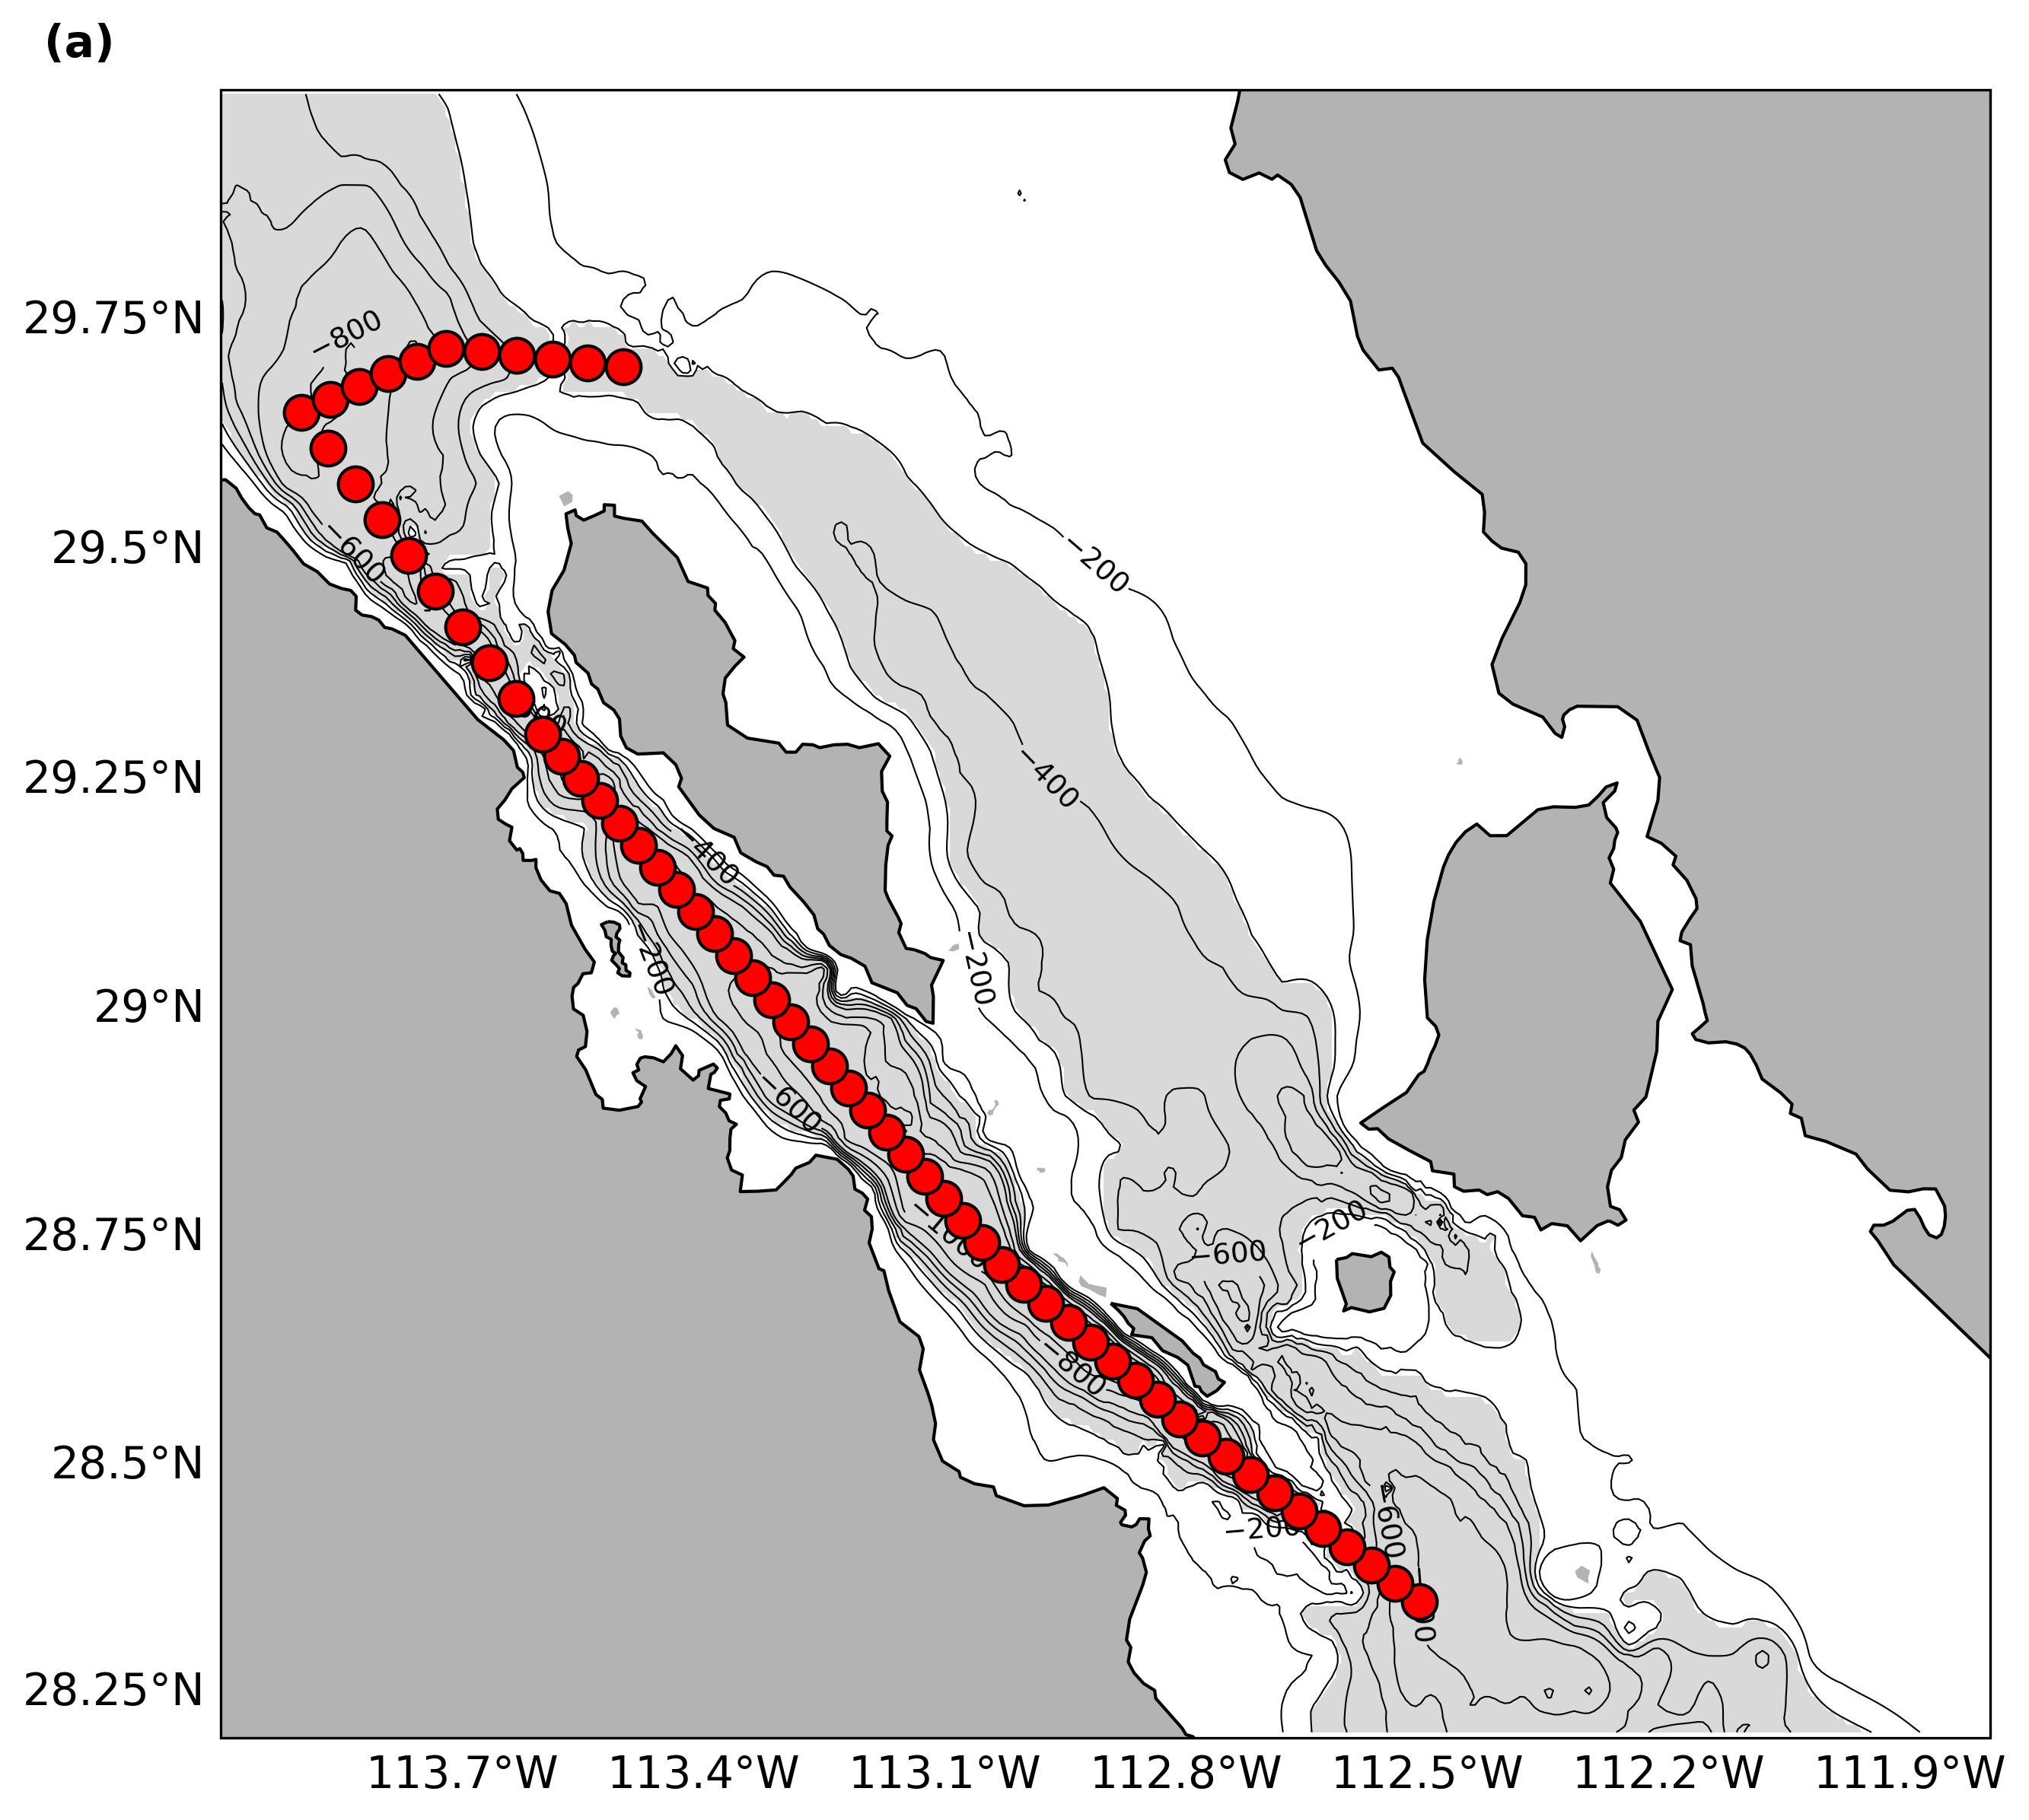

In [16]:

mpl.rcParams['contour.negative_linestyle'] = 'solid'

fig = plt.figure()
gs = GridSpec(nrows=1, ncols=1,wspace=0.001)
proj = ccrs.Mercator()
ax = fig.add_subplot(gs[0:2, 0:2],projection=proj)
ax=map_gol_cal(fig,ax,limites)

ax.text(-0.1, 1.02, '(a)', fontweight='bold', color='k', 
        transform=ax.transAxes)
levels = np.sort([-200, -400, -600, -800, -1000])
levels2 = np.sort([-300, -500])

bat_deep = np.ma.masked_where(bat > -300, bat)

ax.contourf(
    lon_b,
    lat_b,
    np.ma.masked_array(bat_deep,mask=maskin),
    levels=[bat.min(), -300],
    colors=['0.85'],   # light gray
    transform=ccrs.PlateCarree(),
    zorder=0
)

cs = ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin),
    levels=levels,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree(),
    zorder=1
)

ax.contour(
    lon_b,
    lat_b,
    np.ma.masked_array(bat,mask=maskin),
    levels=levels2,
    colors='k',
    linewidths=0.5,
    linestyles='solid',
    transform=ccrs.PlateCarree(),
    zorder=1
)



lon_Baty=np.append(np.append(np.append(np.append(np.append(np.linspace(-112.51,-112.78,10)[:-1],np.linspace(-112.78,-113.03,10))[:-1],np.linspace(-113.03,-113.6,25))[:-1],np.linspace(-113.6,-113.9,10))[:-1],np.linspace(-113.9,-113.72,6))[:-1],np.linspace(-113.72,-113.5,6))#[:-1],np.linspace(-113.5,-113.3,6))#[:-1],np.linspace(-113.3,-113.1,10))
lat_Baty=np.append(np.append(np.append(np.append(np.append(np.linspace(28.35,28.53,10)[:-1],np.linspace(28.53,28.72,10))[:-1],np.linspace(28.72,29.3,25))[:-1],np.linspace(29.3,29.65,10))[:-1],np.linspace(29.65,29.72,6))[:-1],np.linspace(29.72,29.7,6))#[:-1],np.linspace(29.7,29.6,6))#[:-1],np.linspace(29.6,29.35,10))

ax.scatter(
    lon_Baty,lat_Baty,
    s=120,              # marker size (larger for visibility)
    color='r',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

ax.clabel(cs, inline=True, fontsize=9)



fig.tight_layout()
plt.savefig('../realBathy/Figures/Map.png')

In [17]:
np.linspace(29.7,29.6,6)

array([29.7 , 29.68, 29.66, 29.64, 29.62, 29.6 ])

In [18]:
interpBaty = griddata((np.ravel(lat_b),np.ravel(lon_b)), np.ravel(bat),(lat_Baty,lon_Baty))

In [22]:
dist_array_Baty = np.zeros(len(lon_Baty))
p=0
for jj in range(len(lon_Baty)-1):
    lat1 = lat_Baty[jj+1]
    lon1 = lon_Baty[jj+1]
    lat2 = lat_Baty[jj]
    lon2 = lon_Baty[jj]
    p=p+1
    dist_array_Baty[p]=  haversine(lat1, lon1, lat2, lon2)
    
dist_cummul_Baty = np.cumsum(dist_array_Baty)

In [23]:
interpBaty[-4:]=np.max(interpBaty[-5]+29.4)

In [24]:
np.max(interpBaty[:10])

np.float64(-386.8369120582478)

In [25]:
xnew=np.arange(0,dist_cummul_Baty[-1],0.5)

In [26]:
def gaussian(x, mu, sig):
    return (
         np.exp(-np.power((x - mu) / sig, 2.0) / 2)
    )

In [53]:
nyIn=80

dyIn=np.zeros(nyIn)
dyIn[0]=500
for i in np.arange(1,nyIn,1):
    dyIn[i] = dyIn[i-1] + dyIn[i-1]*0.025

ny2=252
dyIn2=np.zeros(ny2)

dyIn2[:80]=np.flip(dyIn)
dyIn2[80:252]=500

dy=np.append(dyIn2,np.flip(dyIn2))
y=np.cumsum(dy)

In [28]:
len(y)-len(xnew)

84

### Ending with a basin in the north

In [29]:
spl = make_smoothing_spline(dist_cummul_Baty, interpBaty, lam=100)
ho=spl(xnew)
runup=gaussian(y[:39]/1000,y[48]/1000,10)*300+(ho[0]-np.max(gaussian(y[:39]/1000,y[48]/1000,10)*300))
infunc=-np.arctan(np.arange(-(len(y)-len(np.append(runup,ho[1:])[:-1]))/3/15,(len(y)-len(np.append(runup,ho[1:])[:-1]))/3/15,1/15))
depin=np.append(np.append(runup,ho[1:])[:-1],((infunc/infunc[0])-1)*120+ho[-1])
dep=np.append(depin,np.ones(len(y)-len(depin))*depin[-1])
splnew = make_smoothing_spline(y, dep, lam=100)
deptry=splnew(y)

#### No basin in the north

In [211]:
spl = make_smoothing_spline(dist_cummul_Baty, interpBaty, lam=100)
ho=spl(xnew)
runup=gaussian(y[:39]/1000,y[48]/1000,10)*300+(ho[0]-np.max(gaussian(y[:39]/1000,y[48]/1000,10)*300))
depin=np.append(runup,ho[1:])
ind=np.argmax(ho[-100:])-100
depin[ind+1:]=np.max(deptry[:300])
deptry=np.append(depin,np.ones(len(y)-len(depin))*depin[-1])


#### With basin in the north but depth of north sill is same as southern sill

In [30]:
spl = make_smoothing_spline(dist_cummul_Baty, interpBaty, lam=100)
ho=spl(xnew)
runup=gaussian(y[:39]/1000,y[48]/1000,10)*300+(ho[0]-np.max(gaussian(y[:39]/1000,y[48]/1000,10)*300))
infunc=-np.arctan(np.arange(-(len(y)-len(np.append(runup,ho[1:])[:-1]))/3/3,(len(y)-len(np.append(runup,ho[1:])[:-1]))/3/3,1/3))
indmax=np.argmax(ho[400:])+400
depin=np.append(np.append(runup,ho[1:indmax]),((infunc/infunc[0])-1)*80+ho[indmax])
depin[len(np.append(runup,ho[1:indmax]))]=depin[len(np.append(runup,ho[1:indmax]))]-0.6
dep=np.append(depin,np.ones(len(y)-len(depin))*depin[-1])
splnew = make_smoothing_spline(y, dep, lam=100)
deptry=splnew(y)

In [31]:
np.max(deptry[400:])

np.float64(-443.41957515613365)

In [32]:
np.argmax(ho[400:])+400

np.int64(407)

In [32]:
np.max(deptry[:200])

np.float64(-443.36464637776686)

In [31]:
nz=80     # number of gridpoints in z-direction
nt=12 #nt=10  #for 3 years with timestep 60 s
dx=0.5
dz=16

OB=15

x=np.arange(0,nx*dx,dx)
z=np.arange(0,nz*dz,dz)

In [32]:
indz600=len(z[z<600])
indzSill=len(z[z<-np.max(ho[ho!=0])])
tempS=np.zeros(nz)
tempS[:indzSill]=np.arange(16,8,(8-16)/indzSill)
tempS[indzSill-1:indz600]=np.arange(tempS[indzSill-1],7,(7-tempS[indzSill-1])/(len(tempS[indzSill-1:indz600])))
tempS[indz600-1:]=np.arange(tempS[indz600-1],5,(5.02-tempS[indz600-1])/(len(tempS[indz600:])))
tempBoS=np.tile(np.tile(tempS,(nx,1)).T,(nt,1,1)).T

In [33]:
ny=504
tempPlot=np.tile(tempS,(ny,1)).T
np.shape(tempPlot)

(80, 504)

In [54]:

h = 80  # total height of the 2D mask

# Create row indices (y-axis)
depmask = np.linspace(0,h*16,80)[:, None]*-1   # shape (h, 1)

# Broadcast comparison
mask = depmask <= deptry  # True = below (masked), False = above

print(mask.astype(int))

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


In [125]:
np.mean(Q[:,:,6])

np.float64(-71.38479695190853)

In [71]:
nxQ=40
nyS=20
Q=np.zeros((nxQ,ny,nt))
Qin=-80*(gaussian(np.arange(12), 5.5, 2))
Q[:,nyS:-nyS,:]=np.tile(Qin,(nxQ,ny-(nyS*2),1))

In [95]:
nyIn=80

dyIn=np.zeros(nyIn)
dyIn[0]=500
for i in np.arange(1,nyIn,1):
    dyIn[i] = dyIn[i-1] + dyIn[i-1]*0.025

ny2=252
dyIn2=np.zeros(ny2)

dyIn2[:80]=np.flip(dyIn)
dyIn2[80:252]=500

dy=np.append(dyIn2,np.flip(dyIn2))


In [55]:
params = {'font.size': 15,
          'figure.figsize': (10, 5),
         'font.family':'sans'}
pl.rcParams.update(params)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300

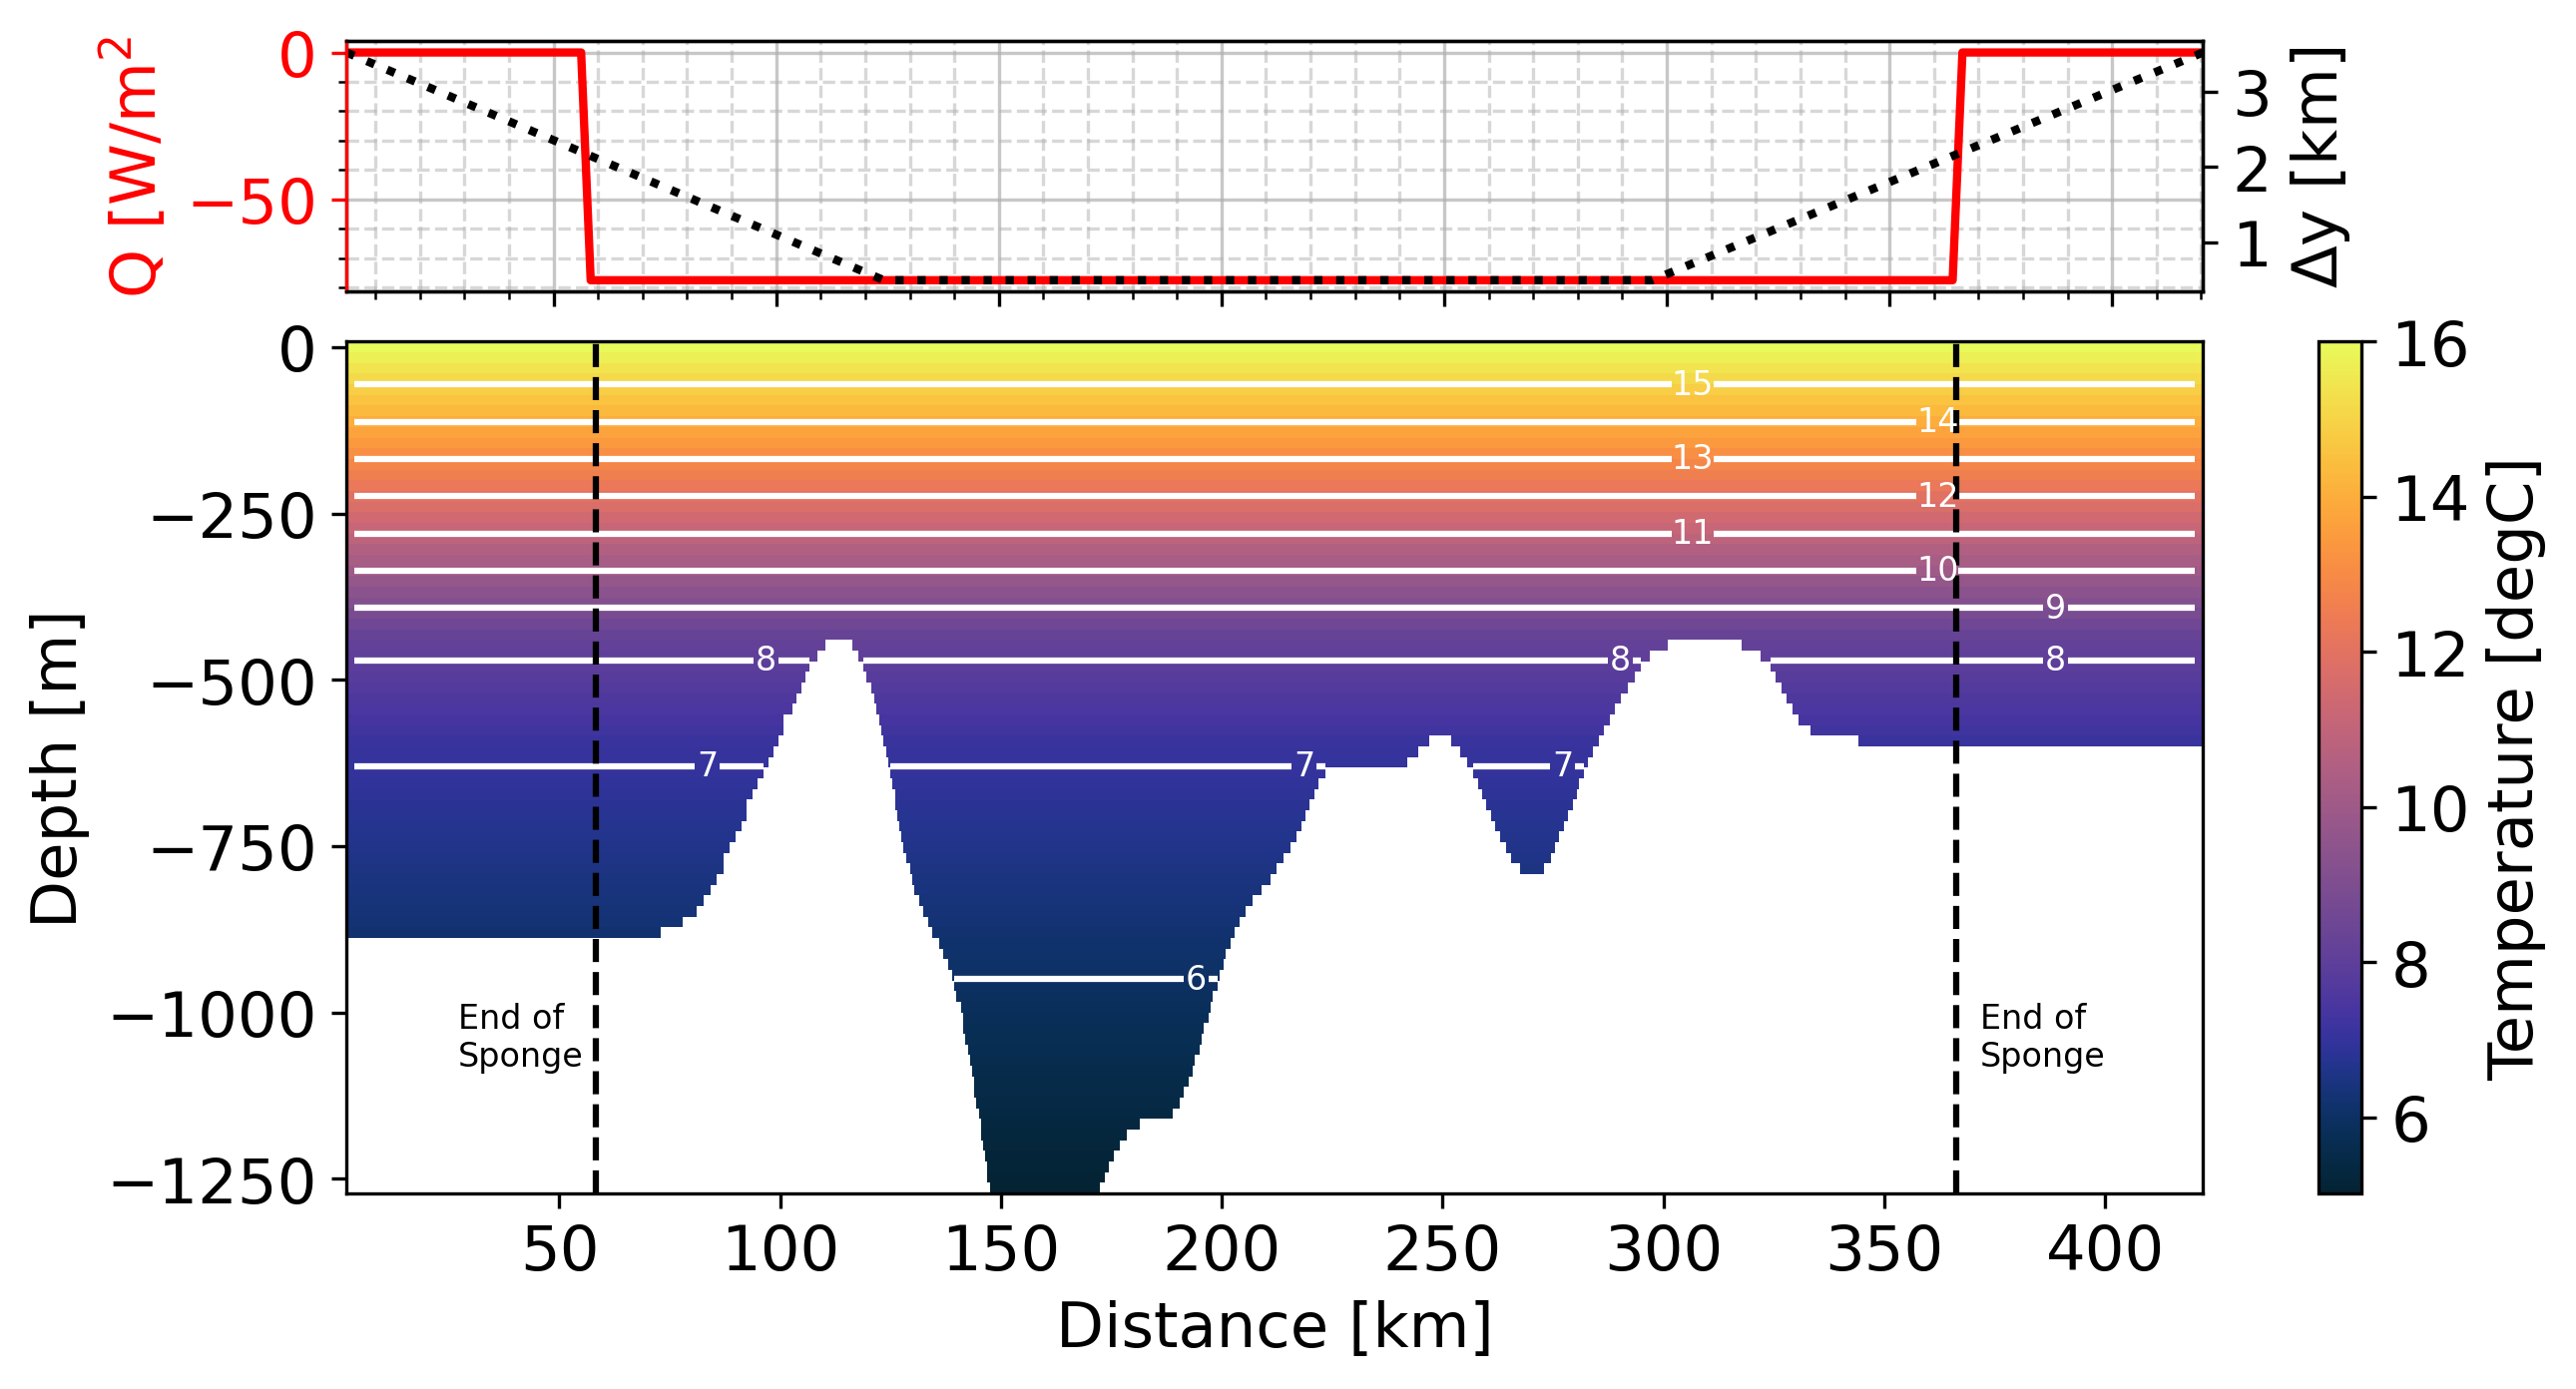

In [114]:

levels=np.arange(6,16,1)
fig = plt.figure()
gs = GridSpec(nrows=4, ncols=10,hspace=0.2,wspace=0.001)

ax = fig.add_subplot(gs[0, :8])
ax.plot(y/1000,Q[20,:,6],color='red',linewidth=2)
ax.set_xlim((np.min(y/1000),np.max(y/1000)))
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=False) 
ax.set_ylabel('Q [W/m$^{2}$',color='red')
ax.tick_params(axis='y', colors='red')


ax2=ax.twinx()
ax2.plot(y/1000,dy/1000,color='k',linestyle='dotted',linewidth=2)
ax2.set(ylabel='$\Delta$y [km]')
ax.minorticks_on()
 

ax.grid(which='minor',linestyle='--', alpha=0.5)
ax.grid(which='major',alpha=0.7)
ax2.spines['left'].set_color('red')

ax = fig.add_subplot(gs[1:, :])
cax=ax.pcolormesh(y/1000,-z,np.ma.masked_array(tempPlot,mask=mask),cmap=cmocean.cm.thermal)
caxC=ax.contour(y/1000,-z,np.ma.masked_array(tempPlot,mask=mask),levels=levels,colors='white')
ax.clabel(caxC, inline=1, fontsize=8)
cbar=plt.colorbar(cax)
cbar.set_label('Temperature [degC]')

#ax.plot(y/1000,deptry,'red')
ax.set(xlabel='Distance [km]',ylabel='Depth [m]')

ax.axvline(y[20]/1000,c='black',linestyle='dashed')
ax.text(0.06, 0.15, 'End of \nSponge', color='black', 
    transform=ax.transAxes,fontsize=8)
ax.axvline(y[-20]/1000,c='black',linestyle='dashed')
ax.text(0.88, 0.15, 'End of \nSponge', color='black', 
    transform=ax.transAxes,fontsize=8)
project='realBathy'
ed='run7/'


plt.savefig('../realBathy/Figures/InputBatyStrat.png', bbox_inches='tight')

In [42]:
nx=40
depOut=np.tile(deptry,(nx,1))
depOut[0,:]=0
depOut[-1,:]=0

In [58]:
def valley_function(x,h,k,a):
    return a*(x-h )**2 + k

In [130]:
xIN=np.arange(0.5,20,0.5)

In [132]:
len(xIN)

39

In [141]:
h=xIN[int(len(xIN)/2)]
depPara=np.zeros((nx,ny))
for i in range(len(deptry)):
    k=dep[i]
    a=-k/np.max(((xIN-h )**2))
    depfunc=valley_function(xIN,h,k,a)
    depfunc[0]=0
    depfunc[-1]=0
    depPara[:,i]=np.insert(depfunc, 20, k)


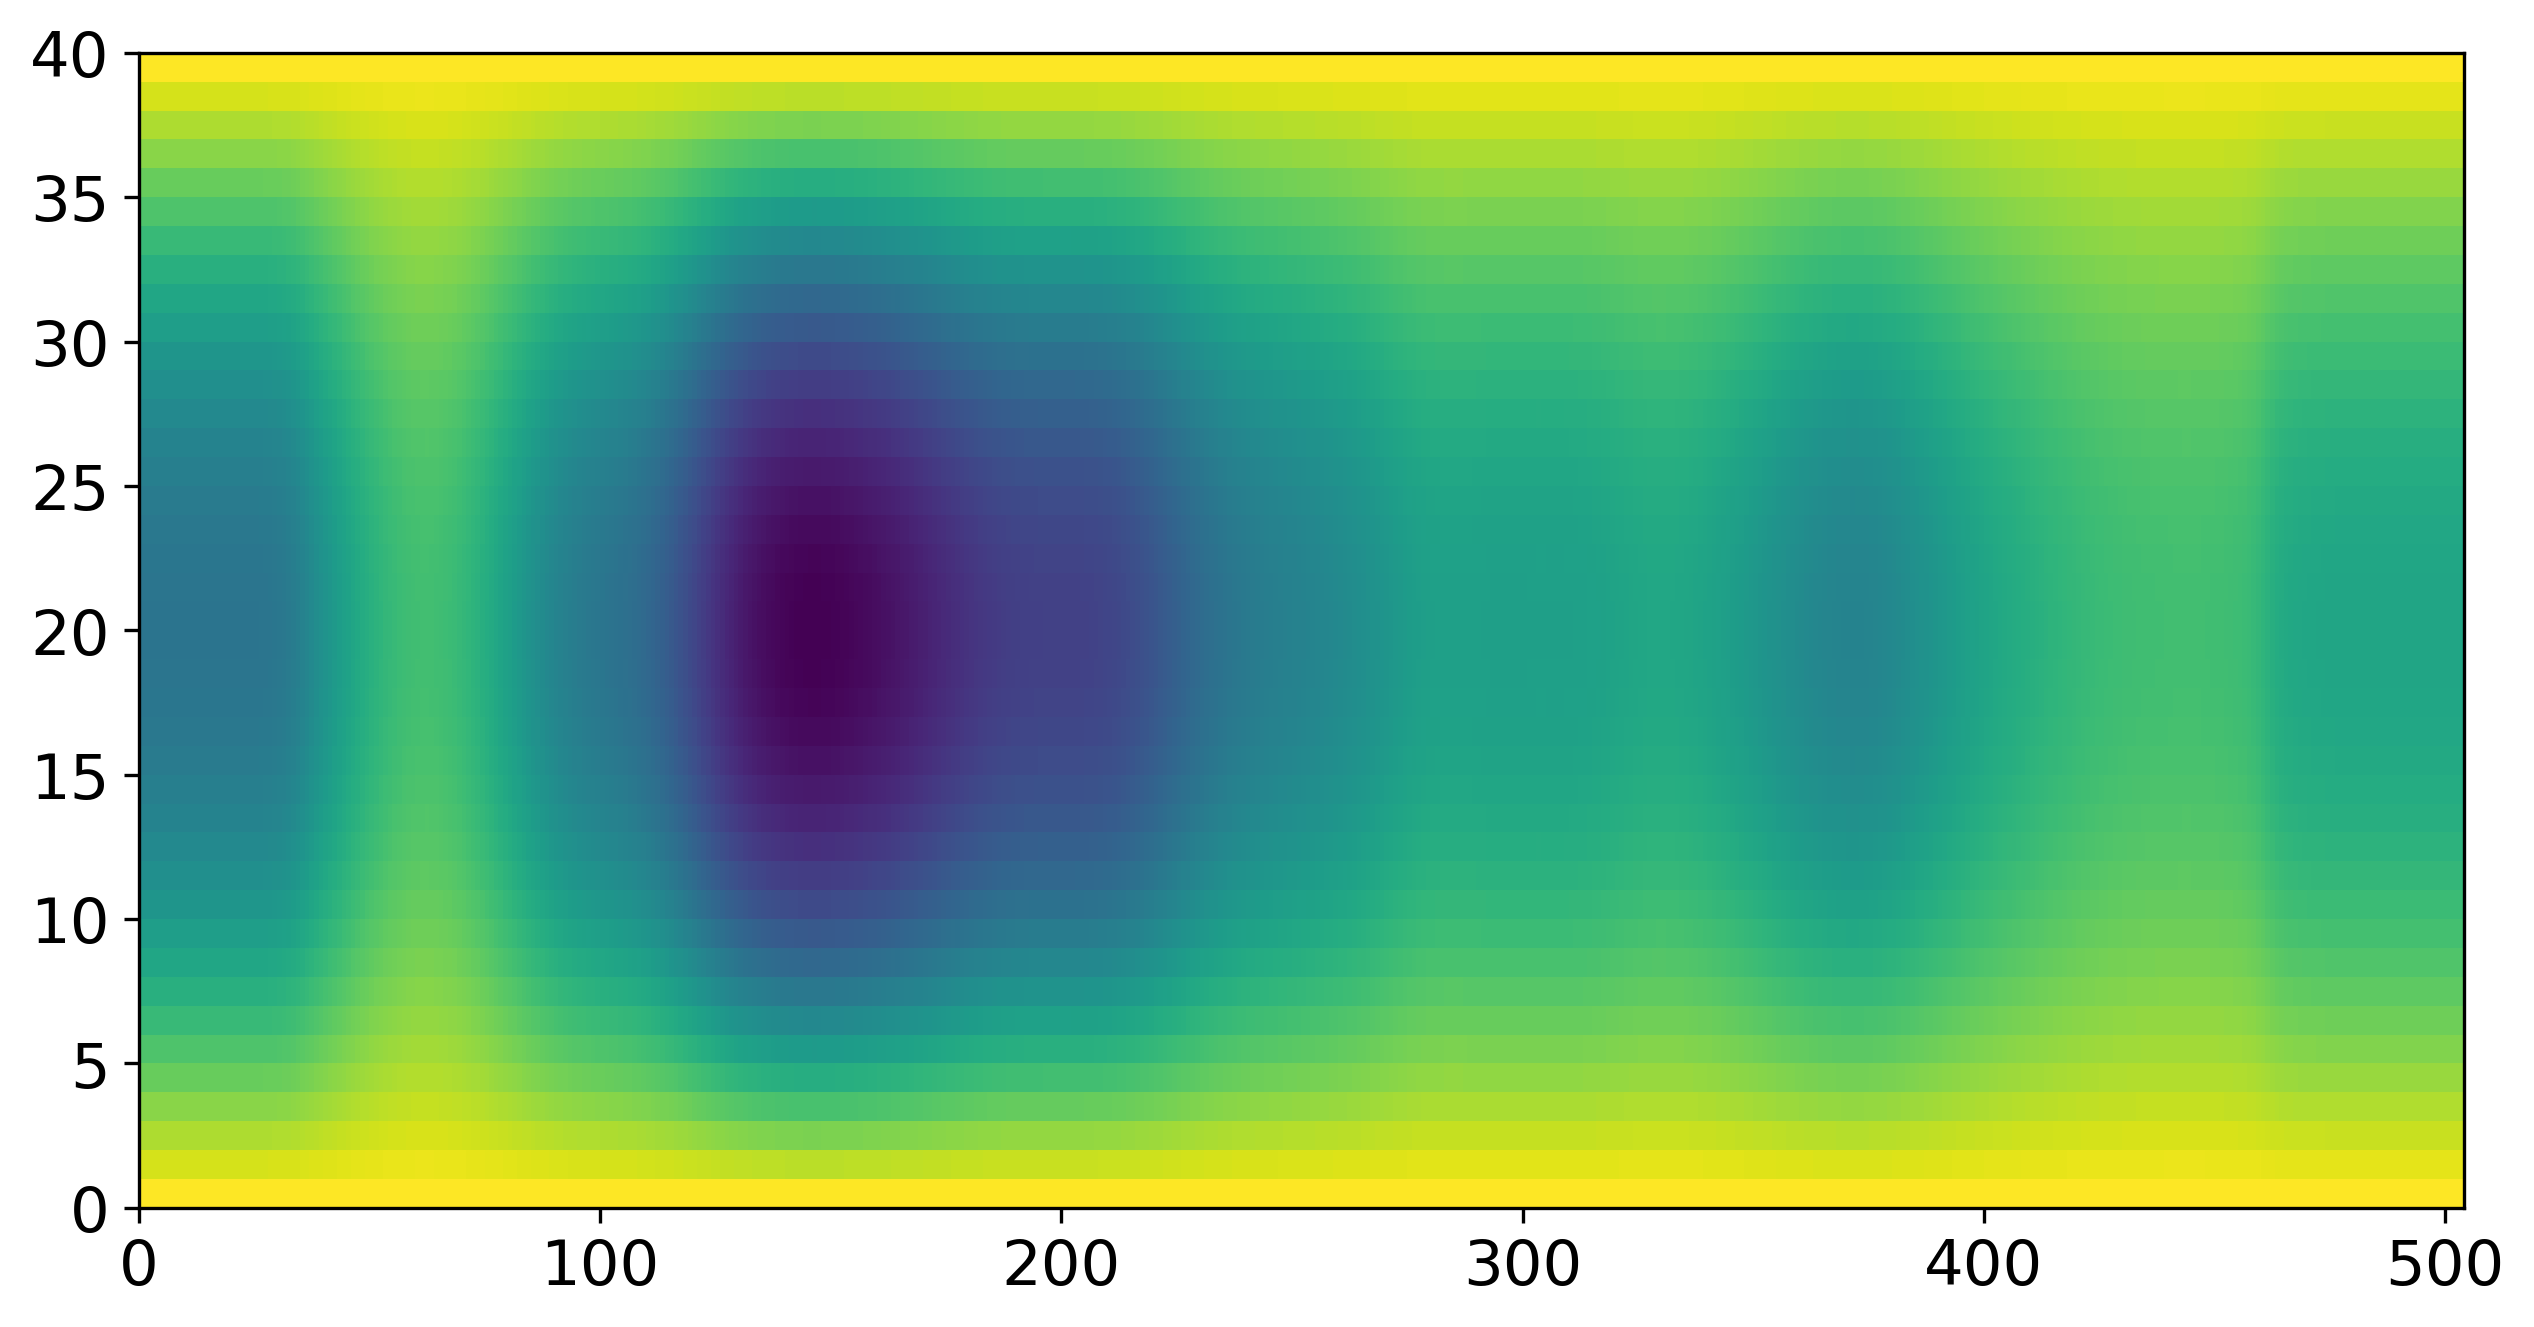

In [155]:
plt.pcolormesh(depPara)

In [156]:

def write_with_byte_inversion(f, tab):
    tab2write = array.array('f', tab.T.flatten())
    if sys.byteorder == 'little':
        tab2write.byteswap()
    f.write(tab2write)

dtype=np.float32

In [157]:
f = open('bathyParabolic.bin','wb')
write_with_byte_inversion(f, depPara)
f.close()

In [502]:


Ho=1280  # ocean depth in meters
nx=40    # number of gridpoints in x-direction
ny=504    # number of total gridpoints in y-direction
nyS=20

nz=80     # number of gridpoints in z-direction
nt=12 #nt=10  #for 3 years with timestep 60 s
dx=0.5
dz=16

OB=15

x=np.arange(0,nx*dx,dx)
z=np.arange(0,nz*dz,dz)





In [332]:
ho[0]

np.float64(-513.2117735316083)

In [287]:
np.max(gaussian(y[:37]/1000,y[45]/1000,10)*300+(ho[0]-np.max(gaussian(y[:37]/1000,y[45]/1000,10)*300)))

np.float64(-703.2238508466783)

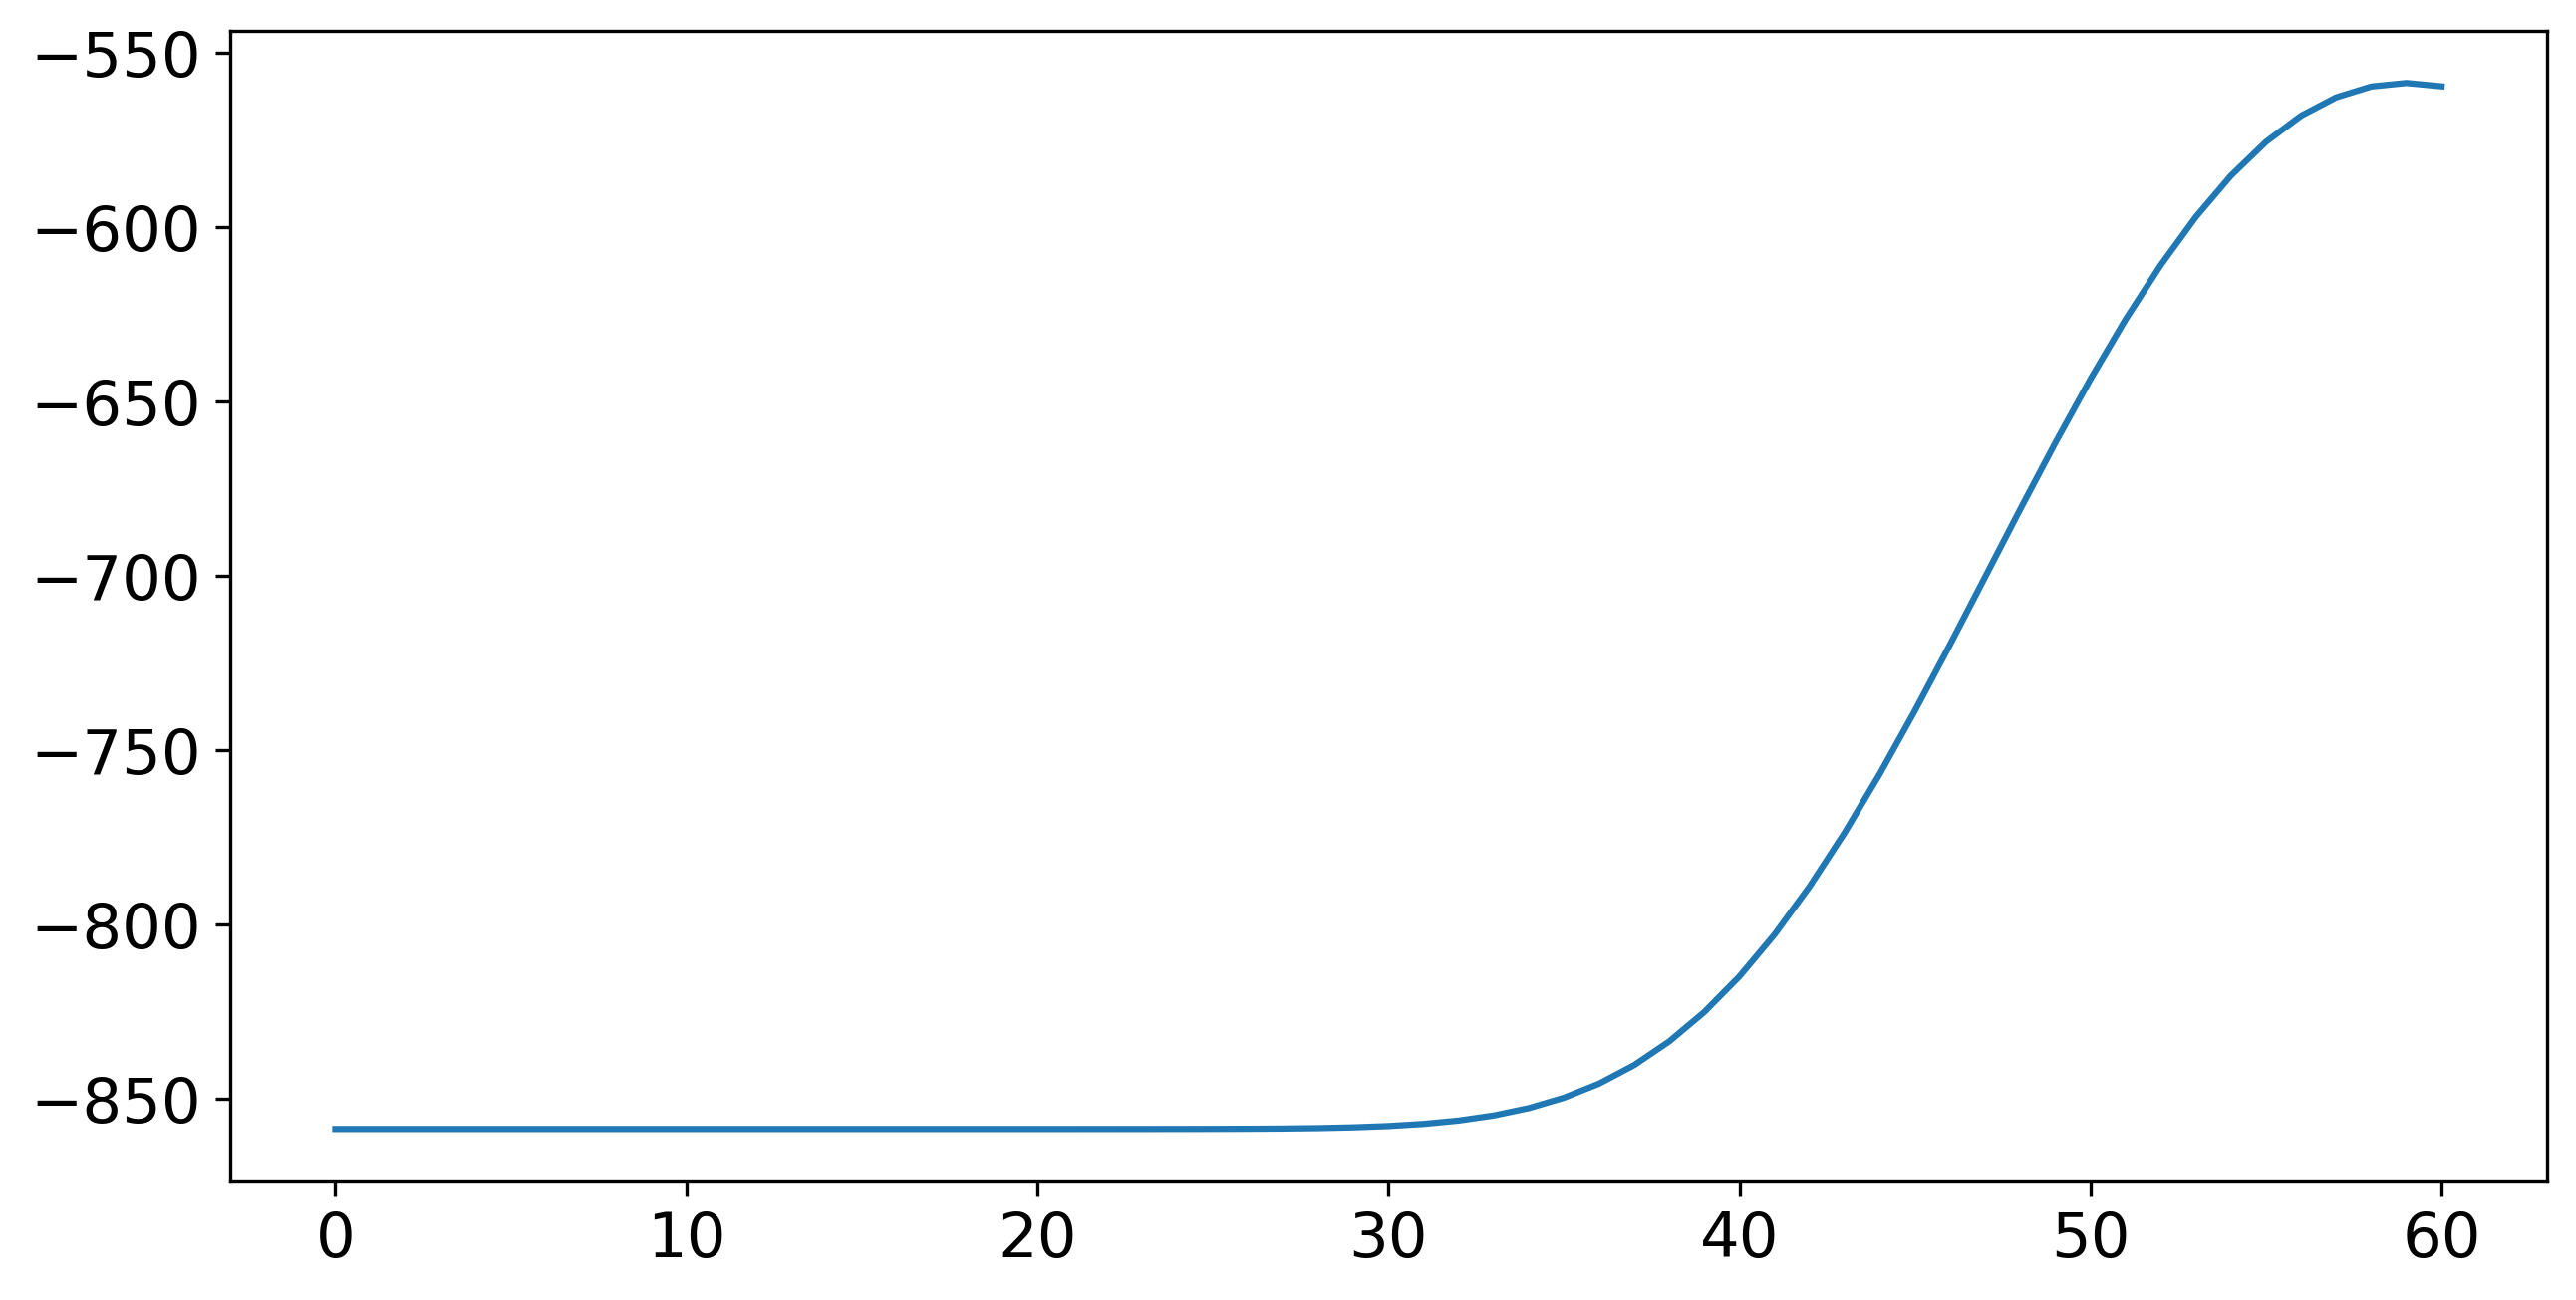

In [158]:
plt.plot(gaussian(y[:61]/1000,y[59]/1000,10)*300+(ho[0]-np.max(gaussian(y[:61]/1000,y[59]/1000,10)*300)))

In [320]:
np.where(y[1:]-y[:-1]==500)

(array([ 78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
        105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
        131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
        144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
        157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
        170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
        183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195,
        196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,
        209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,
        222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234,
        235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247,
        248, 249, 250, 251, 252, 253, 254, 255, 256

In [275]:
## ADDING SILLS IN PLOT
#ax.scatter(
#    lon_umb_cb,lat_umb_cb,
 #   s=300,              # marker size (larger for visibility)
  #  color='k',
   # edgecolor='k',     # optional black border
    #marker='o',
    #transform=ccrs.PlateCarree(),
    #zorder=10          # make sure it's on top of contours and filled areas
#)

#ax.text(lon_umb_cb-0.2,lat_umb_cb, 'BC-Sill', fontweight='bold',fontsize='large', color='k',transform=ccrs.PlateCarree())

#ax.scatter(
    lon_umb_sl,lat_umb_sl,
    s=300,              # marker size (larger for visibility)
    color='k',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

ax.text(lon_umb_sl-0.2,lat_umb_sl, 'SL-Sill', fontweight='bold',fontsize='large', color='k',transform=ccrs.PlateCarree())

ax.scatter(
    lon_umb_se,lat_umb_se,
    s=300,              # marker size (larger for visibility)
    color='k',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

ax.text(lon_umb_se+0.05,lat_umb_se, 'SE-Sill', fontweight='bold',fontsize='large', color='k',transform=ccrs.PlateCarree())

ax.scatter(
    lon_umb_del,lat_umb_del,
    s=300,              # marker size (larger for visibility)
    color='k',
    edgecolor='k',     # optional black border
    marker='o',
    transform=ccrs.PlateCarree(),
    zorder=10          # make sure it's on top of contours and filled areas
)

ax.text(lon_umb_del-0.24,lat_umb_del-0.07, 'DEL-Sill', fontweight='bold',fontsize='large', color='k',transform=ccrs.PlateCarree())


In [ ]:
# -----------------------------
# Save output (.mat)
# -----------------------------
if op_out:
    savemat(
        arch_out,
        {
            "lon_b": lon_b,
            "lat_b": lat_b,
            "bat": bat
        }
    )
